In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')


In [20]:
## Build Index
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

embd = OpenAIEmbeddings()

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/"
]

docs = WebBaseLoader(urls).load()

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size = 500,
    chunk_overlap = 0
)

docs_split = text_splitter.split_documents(docs)

vectorstore = FAISS.from_documents(
    doc_splitted,
    embd
)

In [21]:
retriever = vectorstore.as_retriever()

In [31]:
# retrieval grader
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

# Data model
class GradeModel(BaseModel):
    """Binary score for relevance check of retrieved documents"""
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# LLM with function call
llm = ChatOpenAI(model="gpt-4o", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeModel)


# Prompt
system = """
You are a grader assessing relevance of a retrieved document to a user question.
If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant.
Give a binary score 'yes' or 'no' to indicate the document is relevant to the question.
"""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} from user question: \n\n {question}")
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader


In [37]:
question = "agent memory"
retrieved_docs = retriever.invoke(question)

document = '\n\n'.join(doc.page_content for doc in retrieved_docs)

retrieval_grader.invoke({"document": document, "question": question})

GradeModel(binary_score='yes')

In [46]:
# Generate
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser

#Prompt
prompt = hub.pull('rlm/rag-prompt')

# LLM 
llm = ChatOpenAI(model="gpt-4o", temperature=0)

# format documents
def format_docs(docs):
    return '\n\n'.join(doc.page_content for doc in docs)

# chain
rag_chain = prompt | llm | StrOutputParser()

# run
generation = rag_chain.invoke({"context": document, "question": question})

In [51]:
# question rewriter

llm = ChatOpenAI(model="gpt-4o", temperature=0)

system = """
You are a question re-writer that converts input question to a better version that is optimized for web search.
Look at the input and try to reason about the underlying semantic intent/meaning. 
"""

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Here is the initial question: \n\n {question} \n formulate an improved question.")
    ]
)

question_rewriter = rewrite_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'What is agent memory and how does it function?'

In [61]:
# Search
from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(
    max_results=5,
    topic="general",
)

# results = web_search_tool.invoke({"query": "What is current situation in Iran?"})['results']#


In [66]:
from typing import List, TypedDict

class GraphState(TypedDict):
    """
    Represents the state of the graph.
    Attributes:
        question: The question to be answered.
        generation: LLM generation.
        web_search: whether to add search.
        documents: List of retrieved documents.
    """
    question: str
    generation: str
    web_search: bool
    documents: List[str]

In [123]:
from langchain_core.documents import Document

def retrieve(state: GraphState):
    """
    Retrieve documents
    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print('---------RETRIEVE DOCUMENTS----------')
    question = state['question']

    # retrieve documents
    retrieved_docs = [doc.page_content for doc in retriever.invoke(question)]
    return {"documents": retrieved_docs, "question": question}


def generate(state: GraphState):
    """
    Generate answer
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, generation, that contains the LLM generation
    """
    print('---------GENERATE----------')
    question = state['question']
    documents = state['documents']
    
    # generate answer
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"generation": generation, "question": question, "documents": documents}


def grade_documents(state: GraphState):
    """
    Determine whether the retrieved documents are relevant to the question
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, web_search, that contains whether to add web search
    """
    question = state['question']
    documents = state['documents']

    # Socre each documents
    filtered_docs = []
    web_search = 'No'

    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d}
        )
        grade = score.binary_score

        if grade == 'yes':
            print(f"Document is relevant: {d}")
            filtered_docs.append(d)
        else:
            print(f"Document is not relevant: {d}")
            web_search = 'Yes'


    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def transform_query(state: GraphState):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, question, that contains the transformed question
    """
    print('---------TRANSFORM QUERY----------')
    question = state['question']
    documents = state['documents']
    

    better_question = question_rewriter.invoke({"question": question})
    return {"question": better_question, "documents": documents}

def web_search(state: GraphState):
    """
    Perform web search
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print('---------WEB SEARCH----------')
    question = state['question']
    documents = state['documents']
    
    docs = web_search_tool.invoke({"query": question})
    print(docs['results'])
    web_results = '\n'.join([d['content'] for d in docs['results']])
    web_results = Document(page_content=web_results)
    print(web_results)

    documents.append(web_results.page_content)
    return {"documents": documents, "question": question}


# edge
def decide_to_generate(state: GraphState):
    """
    Determines whether to generate an answer, or re-generate question.

    Args:
        state (dict): The current graph state
    Returns:
        str: Binary decision for the next node
    """
    print("------ASSESS GRADED DOCUMENTS-------")
    question = state['question']
    web_search = state['web_search']
    documents = state['documents']


    if web_search == 'Yes':
        print("--------DECISION: All documents are not relevant to question, transform query----------")
        return "transform_query"
    else:
        print('--------DECISION GRANTED---------------')
        return "generate"

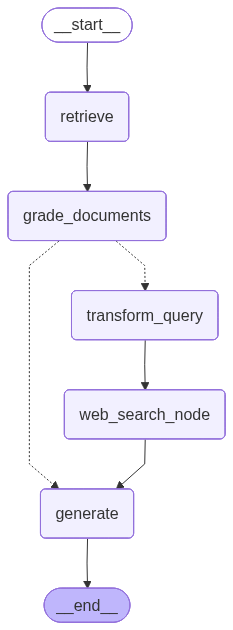

In [124]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(GraphState)

builder.add_node("retrieve", retrieve)
builder.add_node("grade_documents", grade_documents)
builder.add_node("generate", generate)
builder.add_node("transform_query", transform_query)
builder.add_node("web_search_node", web_search)

# edges
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "grade_documents")
builder.add_conditional_edges("grade_documents", decide_to_generate, {"transform_query": "transform_query", "generate": "generate"})
builder.add_edge("transform_query", "web_search_node")
builder.add_edge("web_search_node", "generate")
builder.add_edge("generate", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [126]:
graph.invoke({"question": "Where is taj mahal?"})

---------RETRIEVE DOCUMENTS----------
Document is not relevant: Comparing CoT and PoT. (Image source: Chen et al. 2022).

External APIs#
TALM (Tool Augmented Language Models; Parisi et al. 2022) is a language model augmented with text-to-text API calls. LM is guided to generate |tool-call and tool input text conditioned on task input text to construct API call requests. When |result shows up, the specified tool API is called and the returned result gets appended to the text sequence. The final output is generated following |output token.


The format of API calls in TALM. (Image source: Parisi et al. 2022).
Document is not relevant: Input: What type of water formation is formed by clouds?
Knowledge: Clouds are made of water vapor.

Input: {question}
Knowledge:
And then with model-generated knowledge, prompt the LM further to get the answer.
Programming Language#
Both PAL (Program-aided language models); Gao et al. 2022) and PoT (Program of Thoughts prompting; Chen et al. 2022) ask LLM 

{'question': 'Where is the Taj Mahal located?',
 'generation': 'The Taj Mahal is located in Agra, Uttar Pradesh, India, on the south bank of the Yamuna River.',
 'web_search': 'Yes',
 'documents': ['The Taj Mahal is a world-famous mausoleum located on the south bank of the Yamuna river in Agra, Uttar Pradesh, India. It was built by the Mughal emperor Shah\nThe Taj Mahal, located in Agra, India, is one of the most iconic monuments in the world — a marble mausoleum built by Mughal emperor Shah Jahan\nThe Taj Mahal is a magnificent white marble mausoleum on the southern bank of the Yamuna River in Agra, India. It was built by the Mughal\n* What is the Taj Mahal? * Cultural India - Indian Monuments - Taj Mahal, Agra, Uttar Pradesh, India. # Taj Mahal. ### What is the Taj Mahal? The Taj Mahal is a mausoleum complex in Agra, western Uttar Pradesh state, northern India. The Taj Mahal is a mausoleum complex that houses the tombs of Mumtaz Mahal (“Chosen One of the Palace”) and her husband, the

In [ ]:
graph.invoke({"question": "what is agent memory"})

---------RETRIEVE DOCUMENTS----------


c:\Codebase\GenAI\langgraph_practice\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeModel(binary_score='yes'), input_type=GradeModel])
  return self.__pydantic_serializer__.to_python(


Document is relevant: Memory stream: is a long-term memory module (external database) that records a comprehensive list of agents’ experience in natural language.

Each element is an observation, an event directly provided by the agent.
- Inter-agent communication can trigger new natural language statements.


Retrieval model: surfaces the context to inform the agent’s behavior, according to relevance, recency and importance.

Recency: recent events have higher scores
Importance: distinguish mundane from core memories. Ask LM directly.
Relevance: based on how related it is to the current situation / query.


Reflection mechanism: synthesizes memories into higher level inferences over time and guides the agent’s future behavior. They are higher-level summaries of past events (<- note that this is a bit different from self-reflection above)
Document is relevant: Planning

Subgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient ha

c:\Codebase\GenAI\langgraph_practice\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeModel(binary_score='no'), input_type=GradeModel])
  return self.__pydantic_serializer__.to_python(


Document is not relevant: Comparison of AD, ED, source policy and RL^2 on environments that require memory and exploration. Only binary reward is assigned. The source policies are trained with A3C for "dark" environments and DQN for watermaze.(Image source: Laskin et al. 2023)

Component Two: Memory#
(Big thank you to ChatGPT for helping me draft this section. I’ve learned a lot about the human brain and data structure for fast MIPS in my conversations with ChatGPT.)
Types of Memory#
Memory can be defined as the processes used to acquire, store, retain, and later retrieve information. There are several types of memory in human brains.


Sensory Memory: This is the earliest stage of memory, providing the ability to retain impressions of sensory information (visual, auditory, etc) after the original stimuli have ended. Sensory memory typically only lasts for up to a few seconds. Subcategories include iconic memory (visual), echoic memory (auditory), and haptic memory (touch).
Document is

{'question': 'What is the concept of agent memory in artificial intelligence?',
 'generation': "Agent memory in artificial intelligence refers to an AI system's ability to store, recall, and use information from past interactions to improve decision-making and performance. It includes short-term memory for immediate context and long-term memory for retaining information across sessions, enabling continuity and personalization. This memory system allows AI agents to adapt to changing inputs and maintain coherence in tasks and conversations.",
 'web_search': 'Yes',
 'documents': ['Memory stream: is a long-term memory module (external database) that records a comprehensive list of agents’ experience in natural language.\n\nEach element is an observation, an event directly provided by the agent.\n- Inter-agent communication can trigger new natural language statements.\n\n\nRetrieval model: surfaces the context to inform the agent’s behavior, according to relevance, recency and importance.\

Failed to refresh cache entry rlm/rag-prompt: Connection error caused failure to GET /commits/rlm/rag-prompt/latest in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /commits/rlm/rag-prompt/latest (Caused by NameResolutionError("HTTPSConnection(host=\'api.smith.langchain.com\', port=443): Failed to resolve \'api.smith.langchain.com\' ([Errno 11001] getaddrinfo failed)"))'))
Content-Length: None
API Key: lsv2_********************************************1f
